In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import json

current_folder = Path.cwd()

if current_folder.name == "notebooks":
    project_root = current_folder.parent
else:
    project_root = current_folder

model_file = (
    project_root
    / "models"
    / "final_gradient_boosting_model.joblib"
)

features_file = (
    project_root
    / "models"
    / "final_features.json"
)

final_model = joblib.load(model_file)

with open(features_file, "r") as f:
    final_features = json.load(f)

print("Model loaded successfully!")
print("Number of features:", len(final_features))
print(final_features)

Model loaded successfully!
Number of features: 11
['spo2', 'spo2_lag_1', 'spo2_lag_3', 'spo2_lag_5', 'spo2_change_1min', 'spo2_change_3min', 'spo2_rolling_mean_5', 'spo2_rolling_std_5', 'heart_rate', 'heart_rate_lag_1', 'heart_rate_rolling_mean_5']


In [2]:
gb_model = final_model.named_steps["model"]

print(gb_model)

GradientBoostingRegressor(learning_rate=0.05, max_depth=2, min_samples_leaf=3,
                          n_estimators=200, random_state=42)


In [3]:
feature_importance = pd.DataFrame({
    "Feature": final_features,
    "Importance": gb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,spo2_rolling_mean_5,0.375218
1,spo2,0.290147
2,spo2_lag_1,0.087446
3,heart_rate,0.063723
4,heart_rate_lag_1,0.056692
5,spo2_change_1min,0.030439
6,spo2_rolling_std_5,0.029448
7,spo2_lag_5,0.022692
8,spo2_change_3min,0.018789
9,heart_rate_rolling_mean_5,0.016762


In [4]:
print(
    "Total importance:",
    feature_importance["Importance"].sum()
)

Total importance: 1.0


In [5]:
reports_folder = (
    project_root
    / "reports"
)

reports_folder.mkdir(
    parents=True,
    exist_ok=True
)

importance_file = (
    reports_folder
    / "feature_importance.csv"
)

feature_importance.to_csv(
    importance_file,
    index=False
)

print("Saved to:")
print(importance_file)

Saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\reports\feature_importance.csv


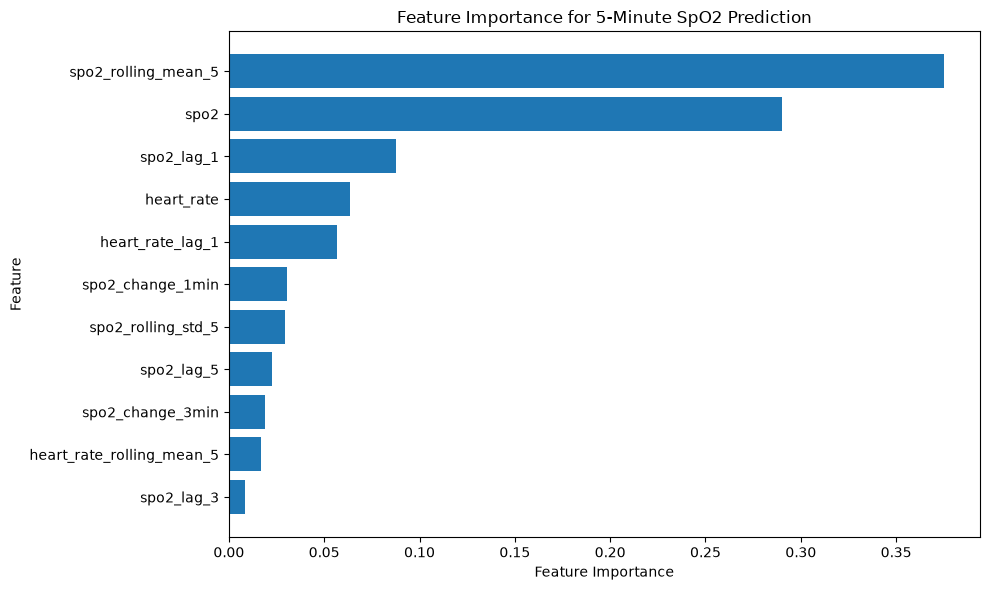

In [6]:
import matplotlib.pyplot as plt

plot_data = feature_importance.sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Feature Importance for 5-Minute SpO2 Prediction"
)

plt.tight_layout()
plt.show()

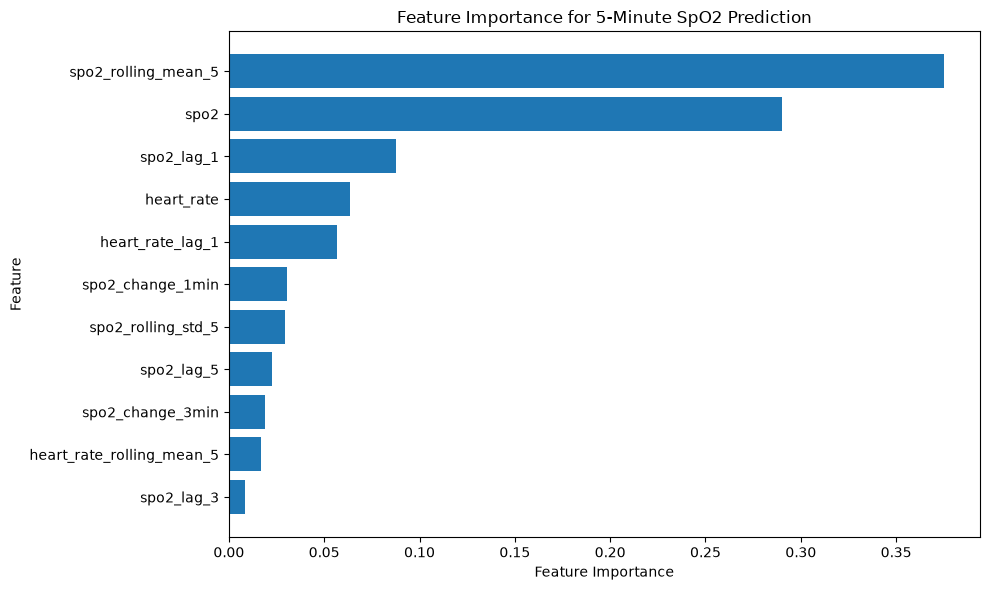

Figure saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\reports\figures\feature_importance.png


In [7]:
figures_folder = (
    project_root
    / "reports"
    / "figures"
)

figures_folder.mkdir(
    parents=True,
    exist_ok=True
)

figure_file = (
    figures_folder
    / "feature_importance.png"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Feature Importance for 5-Minute SpO2 Prediction"
)

plt.tight_layout()

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_file)

In [8]:
predictions_file = (
    project_root
    / "data"
    / "processed"
    / "final_test_predictions.csv"
)

test_predictions = pd.read_csv(
    predictions_file
)

print("Prediction data loaded!")
print("Shape:", test_predictions.shape)

test_predictions.head()

Prediction data loaded!
Shape: (1750, 8)


,caseid,minute,spo2,future_spo2_5min,persistence_prediction,ml_prediction,persistence_error,ml_error
0,10,0,94.0,100.0,94.0,98.476878,6.0,1.523122
1,10,1,95.0,100.0,95.0,98.499796,5.0,1.500204
2,10,2,98.0,100.0,98.0,96.788469,2.0,3.211531
3,10,3,97.0,100.0,97.0,97.254197,3.0,2.745803
4,10,4,98.0,100.0,98.0,98.058429,2.0,1.941571


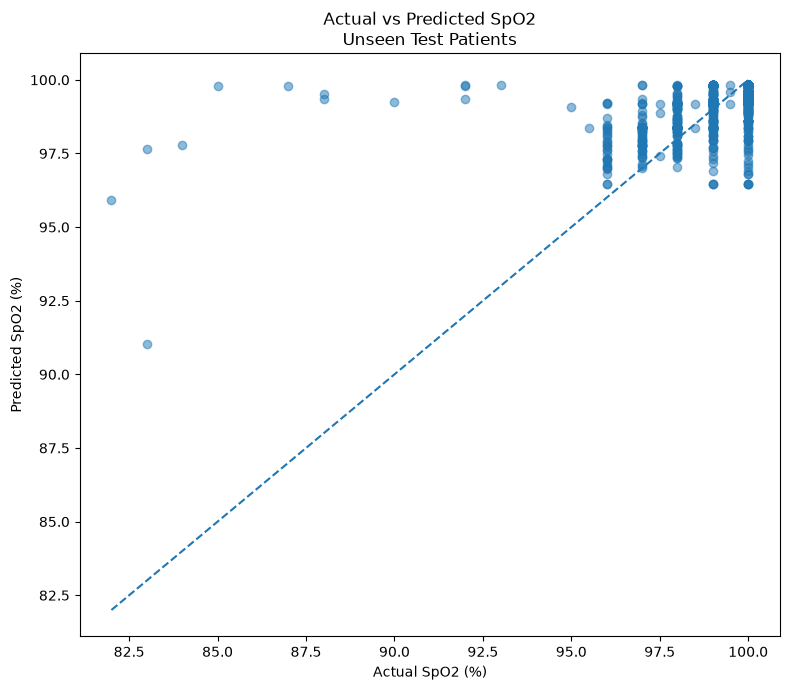

In [9]:
import matplotlib.pyplot as plt

actual = test_predictions["future_spo2_5min"]
predicted = test_predictions["ml_prediction"]

plt.figure(figsize=(8, 7))

plt.scatter(
    actual,
    predicted,
    alpha=0.5
)

minimum = min(
    actual.min(),
    predicted.min()
)

maximum = max(
    actual.max(),
    predicted.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual SpO2 (%)")
plt.ylabel("Predicted SpO2 (%)")

plt.title(
    "Actual vs Predicted SpO2\nUnseen Test Patients"
)

plt.tight_layout()
plt.show()

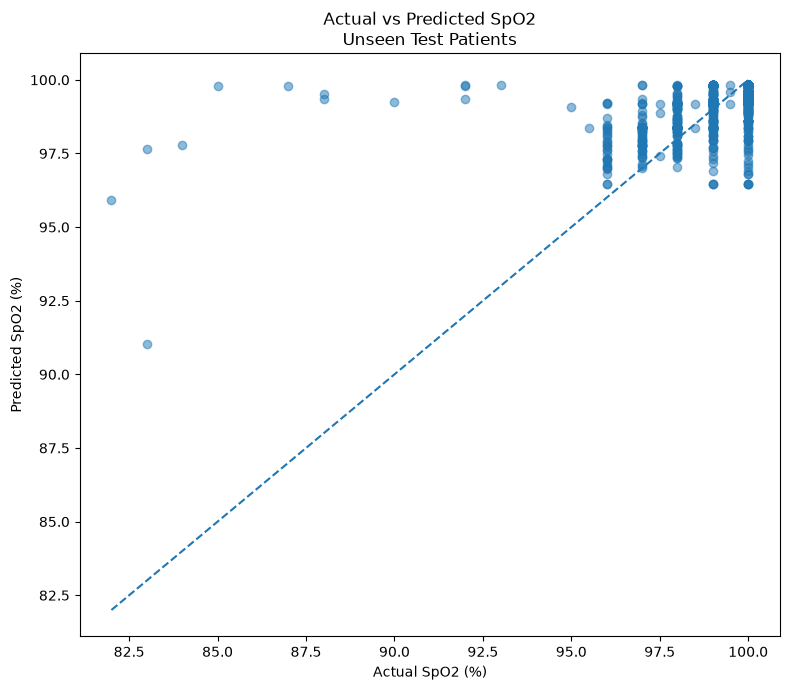

Saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\reports\figures\actual_vs_predicted.png


In [10]:
actual_predicted_file = (
    figures_folder
    / "actual_vs_predicted.png"
)

plt.figure(figsize=(8, 7))

plt.scatter(
    actual,
    predicted,
    alpha=0.5
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual SpO2 (%)")
plt.ylabel("Predicted SpO2 (%)")

plt.title(
    "Actual vs Predicted SpO2\nUnseen Test Patients"
)

plt.tight_layout()

plt.savefig(
    actual_predicted_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(actual_predicted_file)

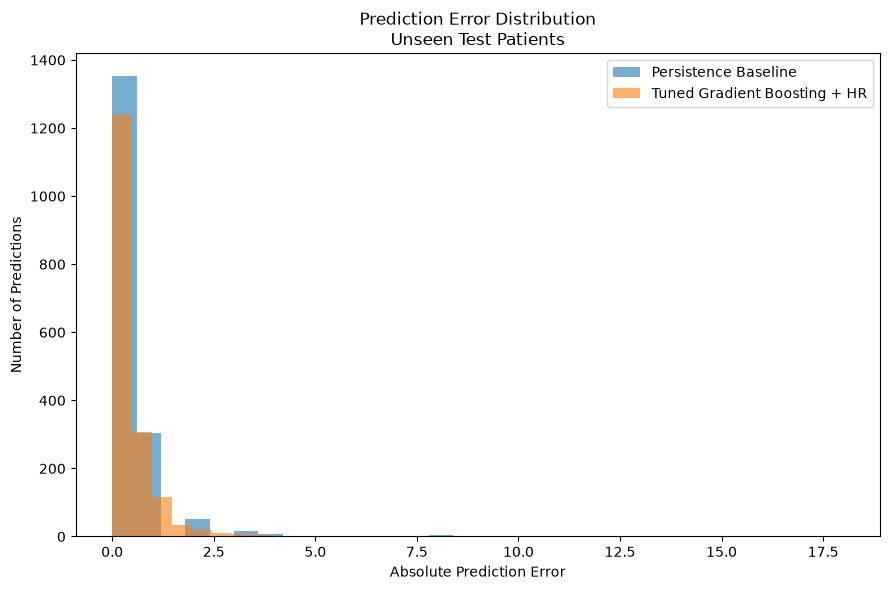

In [11]:
plt.figure(figsize=(9, 6))

plt.hist(
    test_predictions["persistence_error"],
    bins=30,
    alpha=0.6,
    label="Persistence Baseline"
)

plt.hist(
    test_predictions["ml_error"],
    bins=30,
    alpha=0.6,
    label="Tuned Gradient Boosting + HR"
)

plt.xlabel("Absolute Prediction Error")
plt.ylabel("Number of Predictions")

plt.title(
    "Prediction Error Distribution\nUnseen Test Patients"
)

plt.legend()
plt.tight_layout()
plt.show()

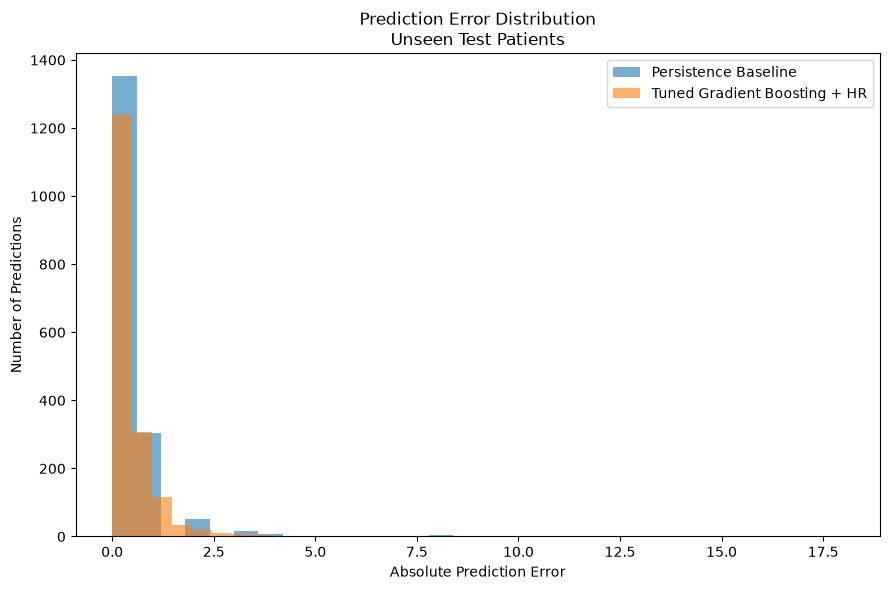

Saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\reports\figures\prediction_error_distribution.png


In [12]:
error_file = (
    figures_folder
    / "prediction_error_distribution.png"
)

plt.figure(figsize=(9, 6))

plt.hist(
    test_predictions["persistence_error"],
    bins=30,
    alpha=0.6,
    label="Persistence Baseline"
)

plt.hist(
    test_predictions["ml_error"],
    bins=30,
    alpha=0.6,
    label="Tuned Gradient Boosting + HR"
)

plt.xlabel("Absolute Prediction Error")
plt.ylabel("Number of Predictions")

plt.title(
    "Prediction Error Distribution\nUnseen Test Patients"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    error_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(error_file)

In [13]:
test_predictions["abs_spo2_change_5min"] = (
    test_predictions["future_spo2_5min"]
    - test_predictions["spo2"]
).abs()

test_predictions["change_group"] = pd.cut(
    test_predictions["abs_spo2_change_5min"],
    bins=[
        -np.inf,
        1,
        3,
        np.inf
    ],
    labels=[
        "Stable (<1 point)",
        "Moderate (1 to <3 points)",
        "Large (3+ points)"
    ],
    right=False
)

test_predictions["change_group"].value_counts().sort_index()

change_group
Stable (<1 point)            1352
Moderate (1 to <3 points)     358
Large (3+ points)              40
Name: count, dtype: int64

In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

test_group_results = []

for group_name, group_df in test_predictions.groupby(
    "change_group",
    observed=True
):

    actual = group_df["future_spo2_5min"]

    for model_name, prediction_column in [
        (
            "Persistence Baseline",
            "persistence_prediction"
        ),
        (
            "Tuned Gradient Boosting + HR",
            "ml_prediction"
        )
    ]:

        predicted = group_df[
            prediction_column
        ]

        mae = mean_absolute_error(
            actual,
            predicted
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )

        test_group_results.append({
            "Model": model_name,
            "Change Group": group_name,
            "Rows": len(group_df),
            "MAE": mae,
            "RMSE": rmse
        })

test_group_results = pd.DataFrame(
    test_group_results
)

test_group_results

,Model,Change Group,Rows,MAE,RMSE
0,Persistence Baseline,Stable (<1 point),1352,0.005547,0.052666
1,Tuned Gradient Boosting + HR,Stable (<1 point),1352,0.277923,0.365333
2,Persistence Baseline,Moderate (1 to <3 points),358,1.146648,1.200268
3,Tuned Gradient Boosting + HR,Moderate (1 to <3 points),358,1.005844,1.186342
4,Persistence Baseline,Large (3+ points),40,5.937500,7.168072
5,Tuned Gradient Boosting + HR,Large (3+ points),40,5.120223,6.633190


In [15]:
test_group_results.sort_values(
    [
        "Change Group",
        "MAE"
    ]
)

,Model,Change Group,Rows,MAE,RMSE
5,Tuned Gradient Boosting + HR,Large (3+ points),40,5.120223,6.633190
4,Persistence Baseline,Large (3+ points),40,5.937500,7.168072
3,Tuned Gradient Boosting + HR,Moderate (1 to <3 points),358,1.005844,1.186342
2,Persistence Baseline,Moderate (1 to <3 points),358,1.146648,1.200268
0,Persistence Baseline,Stable (<1 point),1352,0.005547,0.052666
1,Tuned Gradient Boosting + HR,Stable (<1 point),1352,0.277923,0.365333


In [16]:
test_group_results.sort_values(
    [
        "Change Group",
        "RMSE"
    ]
)

,Model,Change Group,Rows,MAE,RMSE
5,Tuned Gradient Boosting + HR,Large (3+ points),40,5.120223,6.633190
4,Persistence Baseline,Large (3+ points),40,5.937500,7.168072
3,Tuned Gradient Boosting + HR,Moderate (1 to <3 points),358,1.005844,1.186342
2,Persistence Baseline,Moderate (1 to <3 points),358,1.146648,1.200268
0,Persistence Baseline,Stable (<1 point),1352,0.005547,0.052666
1,Tuned Gradient Boosting + HR,Stable (<1 point),1352,0.277923,0.365333


In [17]:
test_subgroup_file = (
    project_root
    / "data"
    / "processed"
    / "final_test_subgroup_results.csv"
)

test_group_results.to_csv(
    test_subgroup_file,
    index=False
)

print("Final test subgroup results saved!")

Final test subgroup results saved!


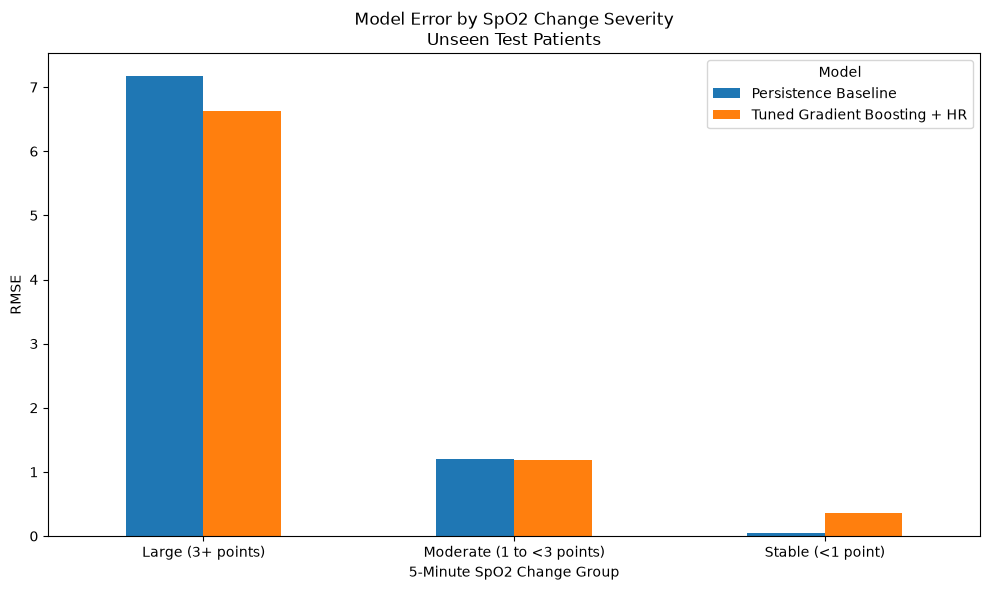

In [18]:
rmse_plot = test_group_results.pivot(
    index="Change Group",
    columns="Model",
    values="RMSE"
)

rmse_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("RMSE")
plt.xlabel("5-Minute SpO2 Change Group")

plt.title(
    "Model Error by SpO2 Change Severity\nUnseen Test Patients"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
test_subgroup_file = (
    project_root
    / "data"
    / "processed"
    / "final_test_subgroup_results.csv"
)

test_group_results.to_csv(
    test_subgroup_file,
    index=False
)

print("Final test subgroup results saved!")
print(test_subgroup_file)

Final test subgroup results saved!
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\data\processed\final_test_subgroup_results.csv


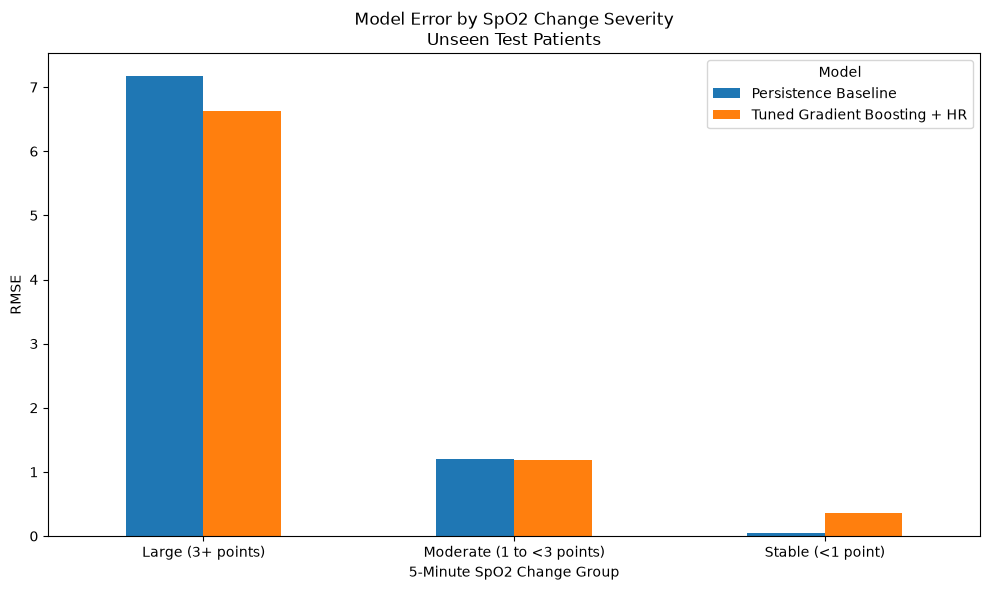

In [21]:
rmse_plot = test_group_results.pivot(
    index="Change Group",
    columns="Model",
    values="RMSE"
)

rmse_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("RMSE")
plt.xlabel("5-Minute SpO2 Change Group")

plt.title(
    "Model Error by SpO2 Change Severity\nUnseen Test Patients"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

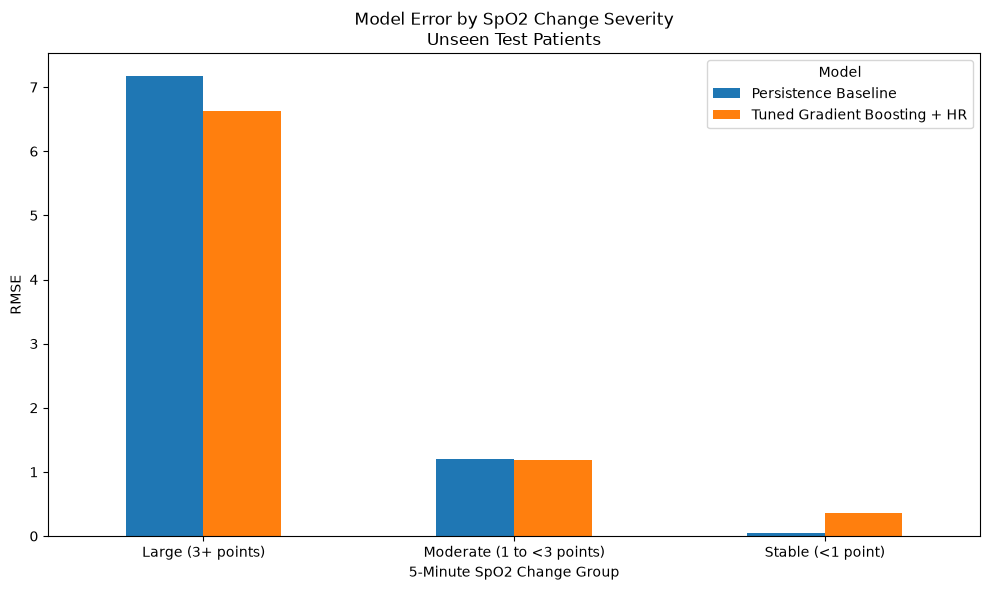

Saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\reports\figures\test_error_by_change_severity.png


In [22]:
subgroup_figure_file = (
    figures_folder
    / "test_error_by_change_severity.png"
)

ax = rmse_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("RMSE")
ax.set_xlabel("5-Minute SpO2 Change Group")

ax.set_title(
    "Model Error by SpO2 Change Severity\nUnseen Test Patients"
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    subgroup_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(subgroup_figure_file)

In [23]:
test_subgroup_file = (
    project_root
    / "data"
    / "processed"
    / "final_test_subgroup_results.csv"
)

test_group_results.to_csv(
    test_subgroup_file,
    index=False
)

print("Final test subgroup results saved!")
print(test_subgroup_file)

Final test subgroup results saved!
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\data\processed\final_test_subgroup_results.csv


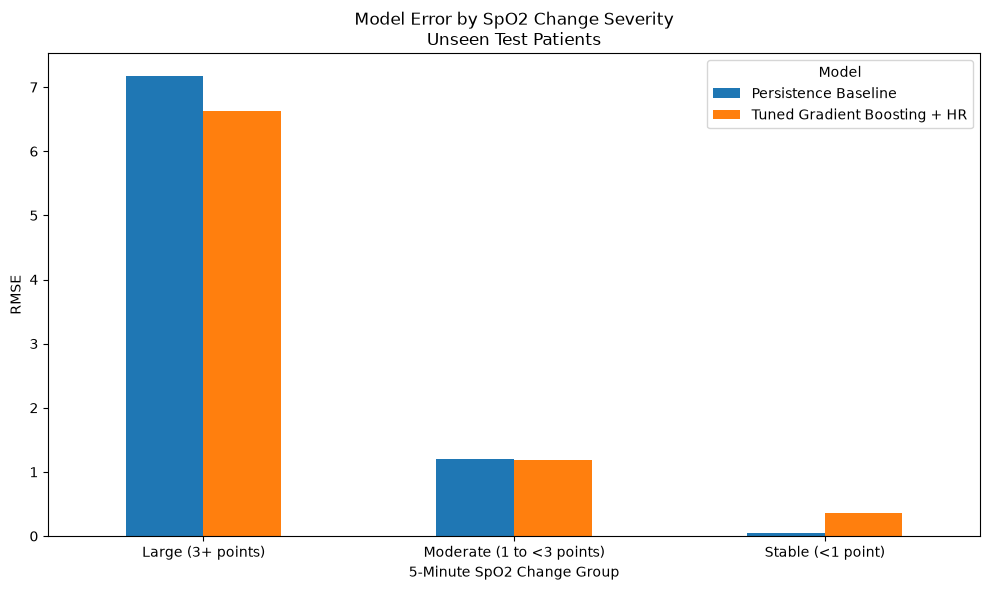

In [24]:
rmse_plot = test_group_results.pivot(
    index="Change Group",
    columns="Model",
    values="RMSE"
)

rmse_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("RMSE")
plt.xlabel("5-Minute SpO2 Change Group")

plt.title(
    "Model Error by SpO2 Change Severity\nUnseen Test Patients"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

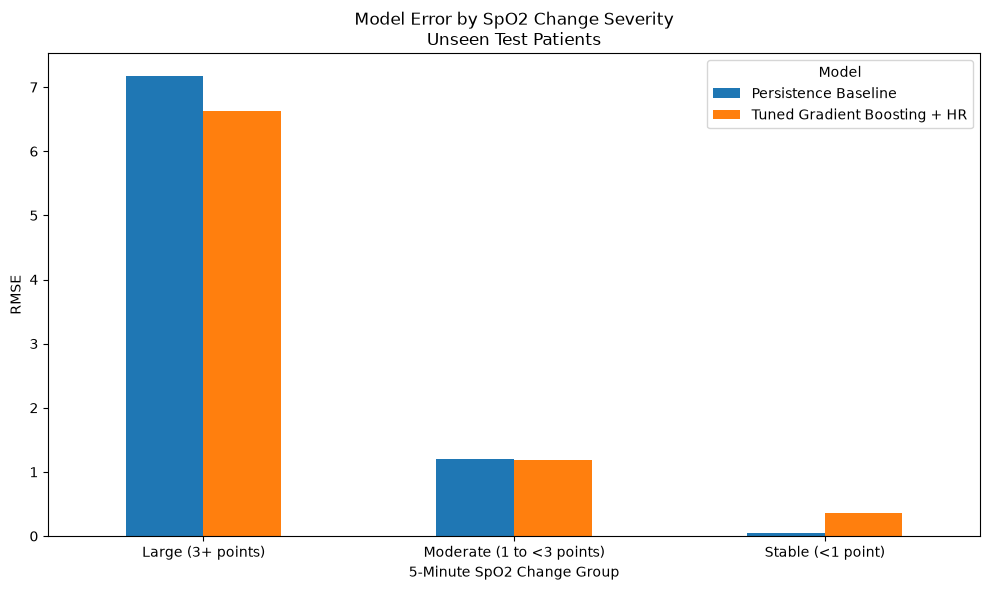

Saved to:
c:\Users\samat\OneDrive\Documents\oxygen-saturation-prediction\reports\figures\test_error_by_change_severity.png


In [25]:
subgroup_figure_file = (
    figures_folder
    / "test_error_by_change_severity.png"
)

ax = rmse_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel("RMSE")
ax.set_xlabel("5-Minute SpO2 Change Group")

ax.set_title(
    "Model Error by SpO2 Change Severity\nUnseen Test Patients"
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    subgroup_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(subgroup_figure_file)

## Final Test Error Analysis

The persistence baseline performed extremely well during stable oxygen-saturation periods because most 5-minute windows showed little or no change in SpO2.

However, the tuned Gradient Boosting model performed better when SpO2 changed meaningfully.

### Unseen Test Patient Findings

- **Stable periods (<1 point change):**
  Persistence remained substantially more accurate.

- **Moderate changes (1 to <3 points):**
  Gradient Boosting reduced MAE from approximately **1.147 to 1.006**.

- **Large changes (3+ points):**
  Gradient Boosting reduced MAE from approximately **5.938 to 5.120**.
  RMSE also decreased from approximately **7.168 to 6.633**.

These findings suggest that a persistence forecast is highly effective when SpO2 remains stable, while temporal SpO2 and heart-rate features provide additional predictive value during periods of changing oxygen saturation.

The change-severity groups were created only for retrospective model evaluation. Future SpO2 values were not used as model input features.

> This project is intended for educational and machine-learning research purposes only and is not intended for clinical diagnosis or medical decision-making.